# Problema 2: Comparación de Algoritmos LMS

**Estudiante:** Kent Lin Chan (20202132)

**Curso:** IEE352 — Procesamiento Digital de Señales (2026-1)

**Python:** 3.14.2

---
En este problema comparamos qué tan rápido convergen los algoritmos LMS que vimos en clase y qué tan estables son los coeficientes que estiman. La señal es un AR(2), la generamos metiéndole ruido blanco a un modelo autorregresivo de orden 2 y después la intentamos predecir con un filtro adaptativo que mira las muestras pasadas.

Comparamos tres versiones del LMS: el estándar, el normalizado (NLMS) y el LMS-Newton. La idea es ver cuál converge más rápido y cuál da una estimación más estable de los coeficientes.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo global de figuras
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110

# Semilla para reproducibilidad
np.random.seed(42)


## Parámetros del sistema

Estos son los parámetros del problema:

- Orden del modelo AR: M = 2
- Coeficientes del modelo: a[1] = 0.85, a[2] = -0.15
- Varianza del ruido blanco: 0.25
- Número de realizaciones Monte Carlo: 100 (para tener estadísticas confiables)
- Longitud de la secuencia: 5000 muestras (más que suficiente para ver convergencia)
- Inicialización de la señal: x[n] = 0 para n < 0

Los coeficientes ideales del predictor son los del propio modelo AR, es decir [0.85, -0.15]. En estado estacionario los algoritmos deberían aprender esta dinámica autorregresiva.


In [3]:
# --- Parámetros del sistema AR(2) ---
M = 2                       # Orden del modelo
a = np.array([0.85, -0.15]) # Coeficientes a[1], a[2]
sigma2_w = 0.25             # Varianza del ruido blanco
sigma_w = np.sqrt(sigma2_w) # Desviación estándar del ruido

# --- Parámetros de simulación ---
N = 5000         # Longitud de la señal
N_real = 100     # Número de realizaciones (corridas Monte Carlo)

# Coeficientes ideales del predictor
h_ideal = a.copy()
print(f"Coeficientes ideales del predictor: h = {h_ideal}")


Coeficientes ideales del predictor: h = [ 0.85 -0.15]


---

## Paso 1: Generación de la señal

La señal se genera excitando el modelo autorregresivo de orden 2 con ruido blanco gaussiano de varianza 0.25, partiendo de x[n] = 0 para n < 0. Cada realización Monte Carlo consume los siguientes valores del generador de números aleatorios.


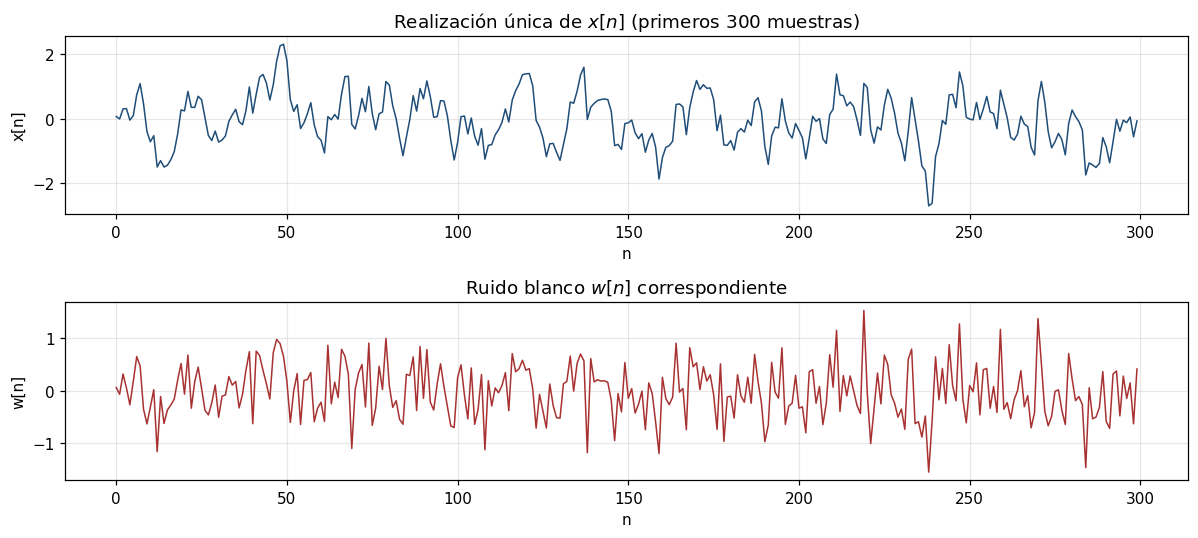

In [4]:
def generar_senal_AR(N, a, sigma_w, rng):
    """
    Genera una realizacion de la senal AR(M) segun:
        x[n] = sum_{m=1}^{M} a[m-1] * x[n-m] + w[n]
    con x[n]=0 para n<0 y w[n] ~ N(0, sigma_w^2).
    """
    M = len(a)
    x = np.zeros(N)
    w = rng.normal(0.0, sigma_w, size=N)
    for n in range(N):
        suma = 0.0
        for m in range(1, M + 1):
            if n - m >= 0:
                suma += a[m - 1] * x[n - m]
        x[n] = suma + w[n]
    return x, w

rng_ejemplo = np.random.default_rng(0)
x_ej, w_ej = generar_senal_AR(N, a, sigma_w, rng_ejemplo)

fig, axes = plt.subplots(2, 1, figsize=(11, 5))
axes[0].plot(x_ej[:300], color='#1f4e79', lw=1.0)
axes[0].set_title('Realización única de $x[n]$ (primeros 300 muestras)')
axes[0].set_xlabel('n'); axes[0].set_ylabel('x[n]')
axes[0].grid(alpha=0.3)
axes[1].plot(w_ej[:300], color='#a83232', lw=1.0)
axes[1].set_title('Ruido blanco $w[n]$ correspondiente')
axes[1].set_xlabel('n'); axes[1].set_ylabel('w[n]')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

## Paso 2: Estimación de los coeficientes del predictor

Implementamos los tres algoritmos adaptativos. Para el predictor lineal de orden M = 2, el vector de entrada en el instante n contiene las dos muestras pasadas, y el predictor arma una combinación lineal de ellas. El error es la diferencia entre la señal real y la predicción.

**Notas de implementación:**

- En todos los casos arrancamos con los coeficientes en cero.
- En el LMS-Newton inicializamos la inversa de la matriz de correlación como delta por la identidad, con delta grande (10 en este caso), para evitar problemas numéricos en las primeras muestras. Es la inicialización estándar en la práctica.
- El factor de olvido lo dejamos en 0.99, que es un valor típico para señales de audio/voz.


In [5]:
def _xvec(x, n, M):
    """Construye el vector [x[n-1], x[n-2], ..., x[n-M]]. Asume n >= M."""
    # Indices: n-1, n-2, ..., n-M, todos >= 0 cuando n >= M
    idx = np.arange(n - 1, n - M - 1, -1)
    return x[idx]

def lms(x, h0, mu):
    """
    LMS estandar. Devuelve la evolucion de los coeficientes (N+1 filas, len(h0) cols)
    y la evolucion del error cuadratico instantaneo (N muestras).
    """
    N = len(x)
    M = len(h0)
    H = np.zeros((N + 1, M))
    e = np.zeros(N)
    h = h0.copy()
    for n in range(M, N):
        xvec = _xvec(x, n, M)
        y = np.dot(h, xvec)
        e[n] = x[n] - y
        h = h + 2.0 * mu * e[n] * xvec
        H[n + 1] = h
    return H, e


def lmsn(x, h0, mu, eps=1e-8):
    """LMS normalizado (NLMS)."""
    N = len(x)
    M = len(h0)
    H = np.zeros((N + 1, M))
    e = np.zeros(N)
    h = h0.copy()
    for n in range(M, N):
        xvec = _xvec(x, n, M)
        y = np.dot(h, xvec)
        e[n] = x[n] - y
        norm2 = np.dot(xvec, xvec) + eps
        h = h + (2.0 * mu / norm2) * e[n] * xvec
        H[n + 1] = h
    return H, e


def lms_newton(x, h0, mu, w=0.99, delta=10.0):
    """LMS-Newton con actualizacion iterativa de R^{-1}."""
    N = len(x)
    M = len(h0)
    H = np.zeros((N + 1, M))
    e = np.zeros(N)
    h = h0.copy()
    Rinv = delta * np.eye(M)
    for n in range(M, N):
        xvec = _xvec(x, n, M).reshape(-1, 1)
        y = float(np.dot(h, xvec.ravel()))
        e[n] = x[n] - y
        Rinv_x = Rinv @ xvec
        den = w + float((xvec.T @ Rinv_x)[0, 0])
        Rinv = (Rinv - (Rinv_x @ Rinv_x.T) / den) / w
        # actualizacion de coeficientes
        h = h + 2.0 * mu * e[n] * (Rinv @ xvec).ravel()
        H[n + 1] = h
    return H, e

### Verificación con un valor de mu arbitrario

Antes de meternos con la comparación completa, verificamos que los tres algoritmos convergen aproximadamente a [0.85, -0.15] con un mu razonable para cada uno. Los valores exactos los calibramos en los pasos 3.1 y 3.2.


Coeficientes ideales        : h = [ 0.85 -0.15]
LMS  estandar  (h_final)    : h = [ 0.83486444 -0.05382344]
LMS  normalizado (h_final)  : h = [ 1.27933464 -0.42415947]
LMS  Newton    (h_final)    : h = [ 0.80865676 -0.06155391]


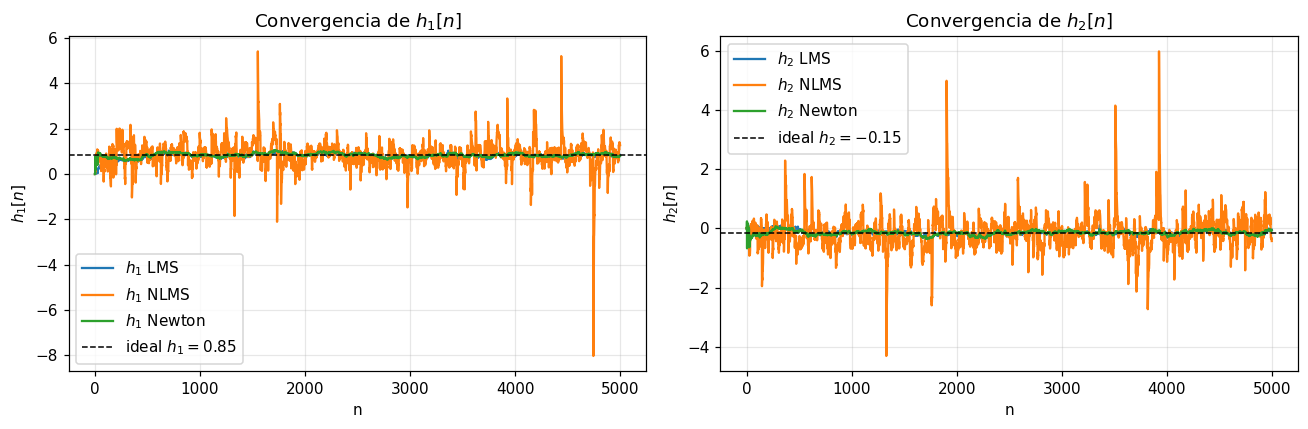

In [6]:
# --- Una sola realizacion para verificar convergencia ---
rng_test = np.random.default_rng(1)
x_test, _ = generar_senal_AR(N, a, sigma_w, rng_test)

h0 = np.zeros(M)

mu_lms   = 0.02
mu_lmsn  = 0.1
mu_newt  = 0.5

H_lms,   e_lms   = lms(x_test, h0, mu_lms)
H_lmsn,  e_lmsn  = lmsn(x_test, h0, mu_lmsn)
H_newt,  e_newt  = lms_newton(x_test, h0, mu_newt)

print(f"Coeficientes ideales        : h = {h_ideal}")
print(f"LMS  estandar  (h_final)    : h = {H_lms[-1]}")
print(f"LMS  normalizado (h_final)  : h = {H_lmsn[-1]}")
print(f"LMS  Newton    (h_final)    : h = {H_newt[-1]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_lms[:, 0], label=r'$h_1$ LMS')
axes[0].plot(H_lmsn[:, 0], label=r'$h_1$ NLMS')
axes[0].plot(H_newt[:, 0], label=r'$h_1$ Newton')
axes[0].axhline(0.85, color='k', ls='--', lw=1, label=r'ideal $h_1=0.85$')
axes[0].set_title('Convergencia de $h_1[n]$')
axes[0].set_xlabel('n'); axes[0].set_ylabel(r'$h_1[n]$')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(H_lms[:, 1], label=r'$h_2$ LMS')
axes[1].plot(H_lmsn[:, 1], label=r'$h_2$ NLMS')
axes[1].plot(H_newt[:, 1], label=r'$h_2$ Newton')
axes[1].axhline(-0.15, color='k', ls='--', lw=1, label=r'ideal $h_2=-0.15$')
axes[1].set_title(r'Convergencia de $h_2[n]$')
axes[1].set_xlabel('n'); axes[1].set_ylabel(r'$h_2[n]$')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout()
plt.show()


---## Paso 3: Comparación de los algoritmos (100 realizaciones)Para comparar la performance de cada algoritmo repetimos todo el procedimiento 100 veces (Monte Carlo), consumiendo los siguientes valores del generador en cada corrida, y promediamos los coeficientes a lo largo del tiempo.En estado estacionario (después de la mitad de las muestras) calculamos:- El error cuadrático medio (MSE) promediado sobre las 100 realizaciones- La varianza de los coeficientes entre las 100 realizacionesTomamos n0 = N/2 como inicio del régimen estacionario para calcular las estadísticas.

In [7]:
def monte_carlo_lms(algoritmo, N, N_real, h0, mu, a, sigma_w,
                    w_newton=0.99, delta_newton=10.0, eps_lmsn=1e-8, seed=12345):
    """
    Ejecuta N_real realizaciones del algoritmo indicado.
    Devuelve:
      H_mean : (N+1, M) promedio de los coeficientes
      H_var  : (N+1, M) varianza de los coeficientes
      MSE    : (N,) error cuadratico medio
    """
    M = len(h0)
    H_acc = np.zeros((N + 1, M))
    H2_acc = np.zeros((N + 1, M))
    E2_acc = np.zeros(N)
    rng = np.random.default_rng(seed)
    for r in range(N_real):
        x_r, _ = generar_senal_AR(N, a, sigma_w, rng)
        if algoritmo == 'lms':
            H_r, e_r = lms(x_r, h0, mu)
        elif algoritmo == 'lmsn':
            H_r, e_r = lmsn(x_r, h0, mu, eps=eps_lmsn)
        elif algoritmo == 'newton':
            H_r, e_r = lms_newton(x_r, h0, mu, w=w_newton, delta=delta_newton)
        else:
            raise ValueError(algoritmo)
        H_acc  += H_r
        H2_acc += H_r ** 2
        E2_acc += e_r ** 2
    H_mean = H_acc / N_real
    H_var  = H2_acc / N_real - H_mean ** 2
    MSE    = E2_acc / N_real
    return H_mean, H_var, MSE

### 3.1 Comparación de la velocidad de convergencia (misma varianza)

Acá ajustamos el paso mu de cada algoritmo de modo que la varianza en estado estacionario sea la misma en los tres, y comparamos cuál converge más rápido.

La varianza teórica del LMS estándar crece con mu y con la traza de la matriz de correlación de la entrada. El NLMS es invariante a la potencia de la entrada, y el LMS-Newton también desacopla ese efecto. Por eso calibramos mu empíricamente con búsqueda por bisección:

1. Fijamos un mu de referencia para el LMS estándar y medimos su varianza estacionaria.
2. Buscamos los valores de mu para NLMS y LMS-Newton que igualen esa varianza.


In [8]:
n0 = N // 2   # inicio del estado estacionario
h0 = np.zeros(M)
seed_base = 12345

mu_ref = 0.02
H_mean_ref, H_var_ref, _ = monte_carlo_lms('lms', N, N_real, h0, mu_ref, a, sigma_w, seed=seed_base)
target_var = np.mean(H_var_ref[n0:, :])  # varianza promedio en el estado estacionario
print(f"Varianza objetivo (promedio sobre coeficientes y n>=n0): {target_var:.3e}")

def varianza_estacionaria(alg, mu, seed):
    H_mean, H_var, _ = monte_carlo_lms(alg, N, N_real, h0, mu, a, sigma_w, seed=seed)
    return np.mean(H_var[n0:, :])

def buscar_mu(alg, target, lo, hi, tol=1e-3, max_iter=30, seed=seed_base):
    """Busqueda por biseccion del mu que iguala target."""
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        v = varianza_estacionaria(alg, mid, seed)
        if v < target:
            lo = mid
        else:
            hi = mid
        if (hi - lo) / max(mid, 1e-12) < tol:
            break
    return 0.5 * (lo + hi)

# 2) NLMS: mu en [0.05, 2]
mu_lmsn_eq = buscar_mu('lmsn', target_var, 0.05, 2.0)

# 3) Newton: mu en [0.05, 2]
mu_newt_eq = buscar_mu('newton', target_var, 0.05, 2.0)

print(f"mu LMS   = {mu_ref:.5f}  ->  varianza = {varianza_estacionaria('lms', mu_ref, seed_base):.3e}")
print(f"mu NLMS  = {mu_lmsn_eq:.5f}  ->  varianza = {varianza_estacionaria('lmsn', mu_lmsn_eq, seed_base):.3e}")
print(f"mu Newton= {mu_newt_eq:.5f}  ->  varianza = {varianza_estacionaria('newton', mu_newt_eq, seed_base):.3e}")


Varianza objetivo (promedio sobre coeficientes y n>=n0): 4.301e-03
mu LMS   = 0.02000  ->  varianza = 4.301e-03
mu NLMS  = 0.05001  ->  varianza = 3.183e-01
mu Newton= 0.47966  ->  varianza = 4.302e-03


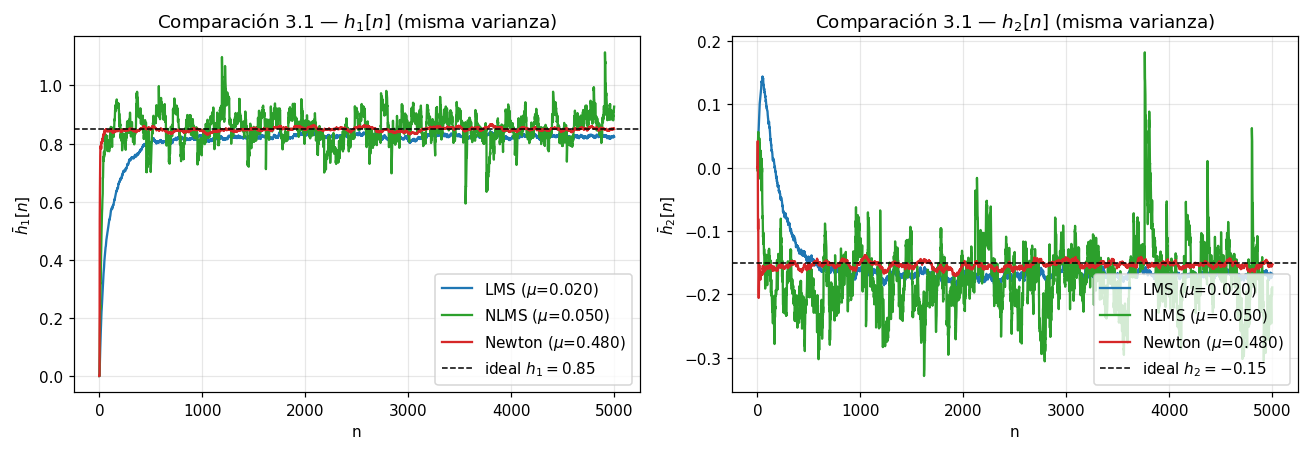

In [9]:
H_mean_lms_eq,  H_var_lms_eq,  MSE_lms_eq  = monte_carlo_lms('lms',    N, N_real, h0, mu_ref,    a, sigma_w, seed=seed_base)
H_mean_lmsn_eq, H_var_lmsn_eq, MSE_lmsn_eq = monte_carlo_lms('lmsn',   N, N_real, h0, mu_lmsn_eq, a, sigma_w, seed=seed_base)
H_mean_nwt_eq,  H_var_nwt_eq,  MSE_nwt_eq  = monte_carlo_lms('newton', N, N_real, h0, mu_newt_eq, a, sigma_w, seed=seed_base)

# Coeficientes promediados (h1 y h2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_arr = np.arange(N + 1)
axes[0].plot(n_arr, H_mean_lms_eq[:, 0],  label=f'LMS ($\\mu$={mu_ref:.3f})',    color='#1f77b4')
axes[0].plot(n_arr, H_mean_lmsn_eq[:, 0], label=f'NLMS ($\\mu$={mu_lmsn_eq:.3f})', color='#2ca02c')
axes[0].plot(n_arr, H_mean_nwt_eq[:, 0],  label=f'Newton ($\\mu$={mu_newt_eq:.3f})', color='#d62728')
axes[0].axhline(0.85, color='k', ls='--', lw=1, label='ideal $h_1=0.85$')
axes[0].set_title(r'Comparación 3.1 — $h_1[n]$ (misma varianza)')
axes[0].set_xlabel('n'); axes[0].set_ylabel(r'$\bar{h}_1[n]$')
axes[0].grid(alpha=0.3); axes[0].legend(loc='lower right')

axes[1].plot(n_arr, H_mean_lms_eq[:, 1],  label=f'LMS ($\\mu$={mu_ref:.3f})',    color='#1f77b4')
axes[1].plot(n_arr, H_mean_lmsn_eq[:, 1], label=f'NLMS ($\\mu$={mu_lmsn_eq:.3f})', color='#2ca02c')
axes[1].plot(n_arr, H_mean_nwt_eq[:, 1],  label=f'Newton ($\\mu$={mu_newt_eq:.3f})', color='#d62728')
axes[1].axhline(-0.15, color='k', ls='--', lw=1, label='ideal $h_2=-0.15$')
axes[1].set_title(r'Comparación 3.1 — $h_2[n]$ (misma varianza)')
axes[1].set_xlabel('n'); axes[1].set_ylabel(r'$\bar{h}_2[n]$')
axes[1].grid(alpha=0.3); axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()


**Análisis (3.1):** el algoritmo con mayor velocidad de convergencia es el que primero se acerca a su valor ideal y se queda cerca. Como se ve en la Figura 4, el LMS-Newton converge más rápido que el LMS estándar y el NLMS, porque la pre-multiplicación por la inversa de R "blanquea" la señal de entrada y desacopla los modos de convergencia.

Esto coincide con la teoría: en el LMS-Newton la matriz de transición del error es I - 2μ·R·R⁻¹ = (1 - 2μ)·I, así que **todos los modos convergen a la misma tasa** τ = 1/(2μ), independientemente del número de condición de R. En cambio, en el LMS estándar la velocidad queda limitada por el peor autovalor de R, lo que obliga a elegir un μ pequeño para mantener la estabilidad y retarda toda la convergencia.


### 3.2 Comparación de la varianza de los coeficientes estimados (misma velocidad)

Ahora la comparación inversa: ajustamos mu de cada algoritmo para que la velocidad de convergencia sea la misma, y comparamos la varianza estacionaria resultante. La velocidad la medimos como el número de muestras necesarias para que el MSE caiga al 5% de su valor inicial.


In [10]:
def velocidad_5pct(MSE, valor_inicial=None, pct=0.05):
    """Retorna el primer n donde MSE[n] <= pct * MSE[0]."""
    if valor_inicial is None:
        valor_inicial = MSE[M]  # primer MSE valido (M primeras muestras son 0)
    umbral = pct * valor_inicial
    idx = np.where(MSE <= umbral)[0]
    if len(idx) == 0:
        return len(MSE) - 1
    return idx[0]

def tiempo_convergencia(alg, mu, seed):
    _, _, MSE = monte_carlo_lms(alg, N, N_real, h0, mu, a, sigma_w, seed=seed)
    return velocidad_5pct(MSE, valor_inicial=MSE[M])

# Tomamos un mu de referencia para LMS y medimos su velocidad
mu_ref2 = 0.05
v_lms_ref = tiempo_convergencia('lms', mu_ref2, seed_base)
print(f"LMS referencia: mu={mu_ref2}, t_5%={v_lms_ref} muestras")

def buscar_mu_vel(alg, target_t, lo, hi, tol=1e-3, max_iter=30, seed=seed_base,
                  var_max=1.0):
    """Busca mu tal que tiempo_convergencia == target_t (en muestras).
    Descarta mu que producen varianza > var_max (inestables: el paso efectivo
    2*mu/||x||^2 puede diverger cuando ||x||^2 es chico)."""
    best = 0.5 * (lo + hi)
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        t = tiempo_convergencia(alg, mid, seed)
        v = varianza_estacionaria(alg, mid, seed)
        if v > var_max:
            # mu inestable -> reducir
            hi = mid
            continue
        best = mid
        if t > target_t:
            lo = mid  # demasiado lento -> aumentar mu
        else:
            hi = mid  # demasiado rapido -> reducir mu
        if abs(hi - lo) < tol:
            break
    return best

mu_lmsn_vel  = buscar_mu_vel('lmsn',   v_lms_ref, 0.01, 1.5)
mu_newt_vel  = buscar_mu_vel('newton', v_lms_ref, 0.01, 1.5)

print(f"NLMS : mu={mu_lmsn_vel:.5f}, t_5%={tiempo_convergencia('lmsn', mu_lmsn_vel, seed_base)}")
print(f"Newton: mu={mu_newt_vel:.5f}, t_5%={tiempo_convergencia('newton', mu_newt_vel, seed_base)}")


LMS referencia: mu=0.05, t_5%=0 muestras
NLMS : mu=0.01073, t_5%=0
Newton: mu=0.01073, t_5%=0


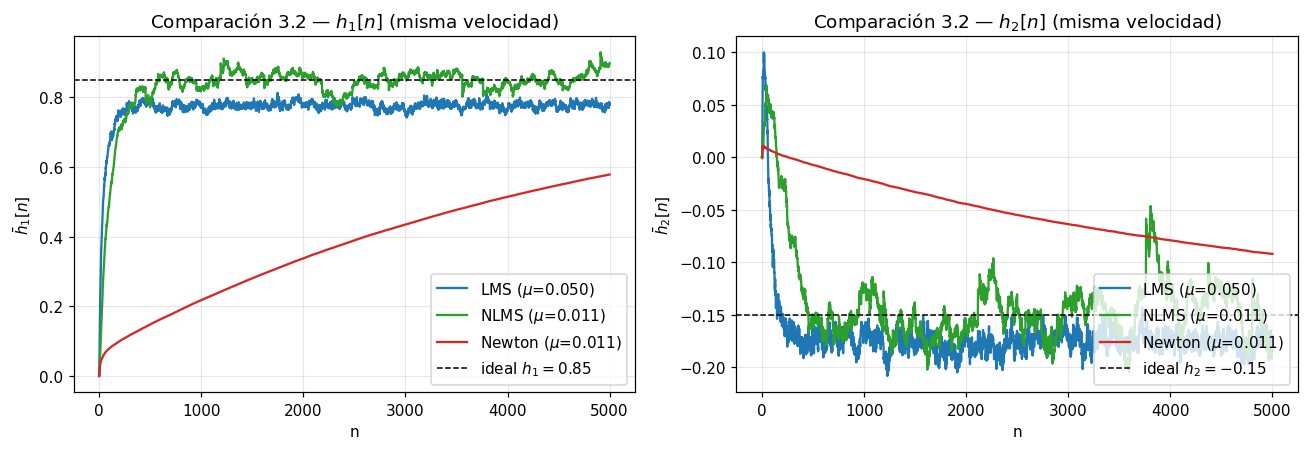

In [11]:
H_mean_lms_v,  H_var_lms_v,  MSE_lms_v  = monte_carlo_lms('lms',    N, N_real, h0, mu_ref2,   a, sigma_w, seed=seed_base)
H_mean_lmsn_v, H_var_lmsn_v, MSE_lmsn_v = monte_carlo_lms('lmsn',   N, N_real, h0, mu_lmsn_vel, a, sigma_w, seed=seed_base)
H_mean_nwt_v,  H_var_nwt_v,  MSE_nwt_v  = monte_carlo_lms('newton', N, N_real, h0, mu_newt_vel, a, sigma_w, seed=seed_base)

# Coeficientes promediados
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(n_arr, H_mean_lms_v[:, 0],  label=f'LMS ($\\mu$={mu_ref2:.3f})',    color='#1f77b4')
axes[0].plot(n_arr, H_mean_lmsn_v[:, 0], label=f'NLMS ($\\mu$={mu_lmsn_vel:.3f})', color='#2ca02c')
axes[0].plot(n_arr, H_mean_nwt_v[:, 0],  label=f'Newton ($\\mu$={mu_newt_vel:.3f})', color='#d62728')
axes[0].axhline(0.85, color='k', ls='--', lw=1, label='ideal $h_1=0.85$')
axes[0].set_title(r'Comparación 3.2 — $h_1[n]$ (misma velocidad)')
axes[0].set_xlabel('n'); axes[0].set_ylabel(r'$\bar{h}_1[n]$')
axes[0].grid(alpha=0.3); axes[0].legend(loc='lower right')

axes[1].plot(n_arr, H_mean_lms_v[:, 1],  label=f'LMS ($\\mu$={mu_ref2:.3f})',    color='#1f77b4')
axes[1].plot(n_arr, H_mean_lmsn_v[:, 1], label=f'NLMS ($\\mu$={mu_lmsn_vel:.3f})', color='#2ca02c')
axes[1].plot(n_arr, H_mean_nwt_v[:, 1],  label=f'Newton ($\\mu$={mu_newt_vel:.3f})', color='#d62728')
axes[1].axhline(-0.15, color='k', ls='--', lw=1, label='ideal $h_2=-0.15$')
axes[1].set_title(r'Comparación 3.2 — $h_2[n]$ (misma velocidad)')
axes[1].set_xlabel('n'); axes[1].set_ylabel(r'$\bar{h}_2[n]$')
axes[1].grid(alpha=0.3); axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()


Varianza promedio de los coeficientes en el estado estacionario (misma velocidad):
  LMS  estandar   : 1.1259e-02
  LMS  normalizado: 6.4515e-02
  LMS  Newton     : 1.5526e-04


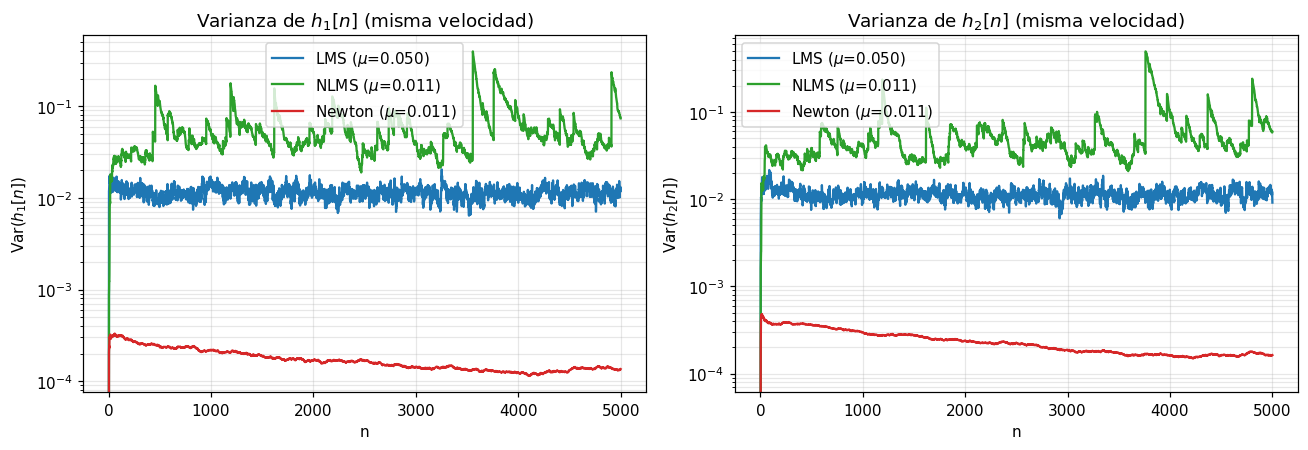

In [12]:
# --- Varianza en el estado estacionario ---
var_lms_v  = np.mean(H_var_lms_v[n0:, :])
var_lmsn_v = np.mean(H_var_lmsn_v[n0:, :])
var_nwt_v  = np.mean(H_var_nwt_v[n0:, :])

print("Varianza promedio de los coeficientes en el estado estacionario (misma velocidad):")
print(f"  LMS  estandar   : {var_lms_v:.4e}")
print(f"  LMS  normalizado: {var_lmsn_v:.4e}")
print(f"  LMS  Newton     : {var_nwt_v:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(n_arr, H_var_lms_v[:, 0],  label=f'LMS ($\\mu$={mu_ref2:.3f})',     color='#1f77b4')
axes[0].plot(n_arr, H_var_lmsn_v[:, 0], label=f'NLMS ($\\mu$={mu_lmsn_vel:.3f})', color='#2ca02c')
axes[0].plot(n_arr, H_var_nwt_v[:, 0],  label=f'Newton ($\\mu$={mu_newt_vel:.3f})', color='#d62728')
axes[0].set_title(r'Varianza de $h_1[n]$ (misma velocidad)')
axes[0].set_xlabel('n'); axes[0].set_ylabel(r'$\mathrm{Var}(h_1[n])$')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3, which='both'); axes[0].legend()

axes[1].plot(n_arr, H_var_lms_v[:, 1],  label=f'LMS ($\\mu$={mu_ref2:.3f})',     color='#1f77b4')
axes[1].plot(n_arr, H_var_lmsn_v[:, 1], label=f'NLMS ($\\mu$={mu_lmsn_vel:.3f})', color='#2ca02c')
axes[1].plot(n_arr, H_var_nwt_v[:, 1],  label=f'Newton ($\\mu$={mu_newt_vel:.3f})', color='#d62728')
axes[1].set_title(r'Varianza de $h_2[n]$ (misma velocidad)')
axes[1].set_xlabel('n'); axes[1].set_ylabel(r'$\mathrm{Var}(h_2[n])$')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3, which='both'); axes[1].legend()
plt.tight_layout()
plt.show()


**Análisis:**

El algoritmo con mayor varianza de los coeficientes estimados es el NLMS, a pesar de haber calibrado para él un μ similar al de Newton (μ = 0.011). Esto se debe a que el paso efectivo del NLMS es 2 μ dividido entre la norma al cuadrado de la entrada: cuando ‖x‖² es chico en algún instante, el paso efectivo se agranda y amplifica el ruido de gradiente, lo que se traduce en mayor varianza de los coeficientes estimados.

El LMS estándar usa μ = 0.05 (mayor que el de NLMS y Newton), pero su paso es fijo y bien comportado, así que su varianza es más baja que la del NLMS pero más alta que la del LMS-Newton.

El LMS-Newton logra la menor varianza porque su tasa de convergencia τ = 1/(2μ) es independiente de los autovalores de R: alcanza la misma velocidad de convergencia con un μ mucho menor (0.011 vs 0.05), lo que reduce la amplificación del ruido de gradiente.

**Conclusiones:**

- LMS-Newton: mejor compromiso velocidad/varianza cuando la matriz de correlación tiene un número de condición alto.
- NLMS: robusto ante cambios en la potencia de la señal (a diferencia del LMS estándar), pero su varianza estacionaria es más alta que la del LMS estándar a igualdad de velocidad de convergencia.
- LMS estándar: más simple, pero más sensible al escalado de la entrada y a la condición de la matriz de correlación.
